In [1]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

import itertools

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty s

Text(0.5, 0, 'Powerlaw, $-\\alpha$')

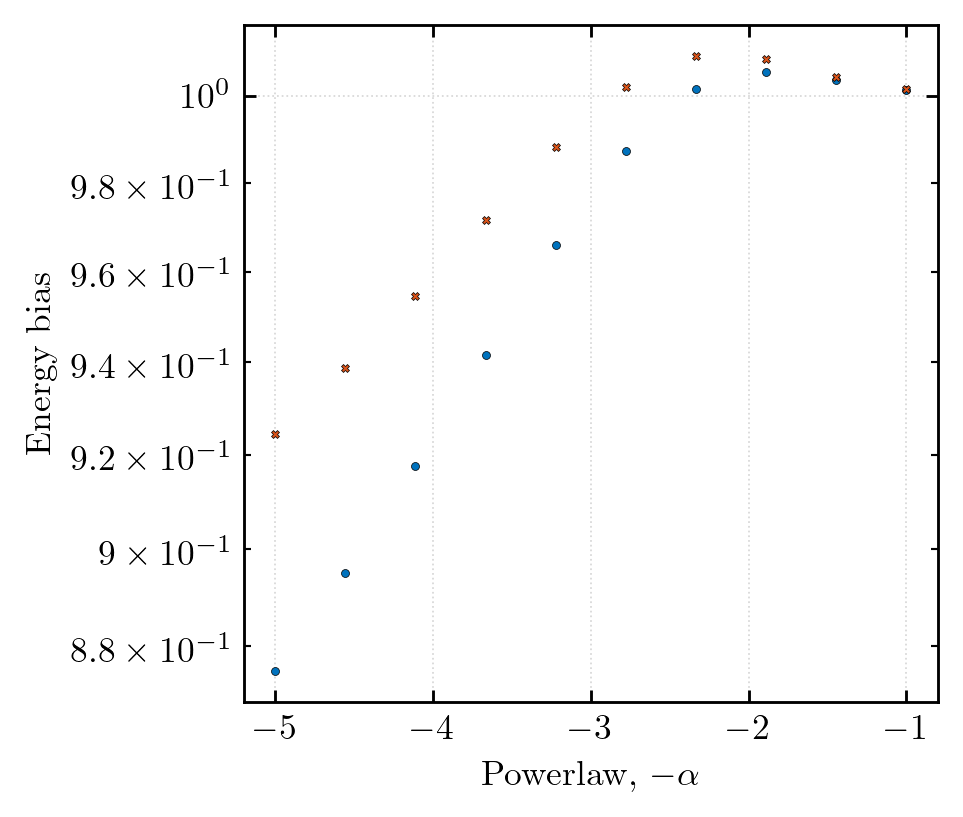

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

amin, amax = -(D+3.), -1.
NUM = 10
alphas = np.linspace(amax, amin, NUM)
np.random.seed(1234)

BREAK = N//4 * dk

fields = []
for a in alphas:
    #fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a, -10.), gfunc='smooth_pow', func_kwargs={'breaks': (BREAK,)}))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))
sfs = []
bin_sfs = []
ospecs = []
mspecs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    _ko, _feko, wo = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nansum, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_loc='center',
            cut_excess=True, nan_small=False)
    ospecs.append((_ko, _feko, wo))
    _km, _fekm, wm = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_loc='center',
            cut_excess=True, nan_small=False)
    mspecs.append((_km, _fekm, wm))

    lv = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
    sf = strfn.process_lags(f, f, lv, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=True)[0]
    sfs.append(sf)

    lvm = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx

    bin_l, bin_sf, w = statistics_base.bin_data(lvm, sf, bin_func=np.nanmean,
        cut_excess=True, nan_small=False,
        min_bin=dx, bin_loc='center')

    bin_sfs.append((bin_l, bin_sf, w))

    idxs = list(itertools.product([N, N//3]))

    idx = [n for n in grid_dims]
    idx[0] = N//3
    e_parsevals1 = sf[tuple(idx)]/2.#np.nanmax(sf)/2.

    e_parsevals2 = bin_sf[N//3]/2.#np.nanmax(bin_sf[-1])/2.

    ax.scatter(alphas[i], e_parsevals1/energies[i], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    ax.scatter(alphas[i], e_parsevals2/energies[i], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

ax.set_yscale('log')
#plt.ylim((9e-1, 1.1e0))

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Energy bias')
ax.set_xlabel('Powerlaw, $-\\alpha$')

In [3]:
cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
upper_cmap = mpl.colors.LinearSegmentedColormap.from_list('Upper', cols)
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))

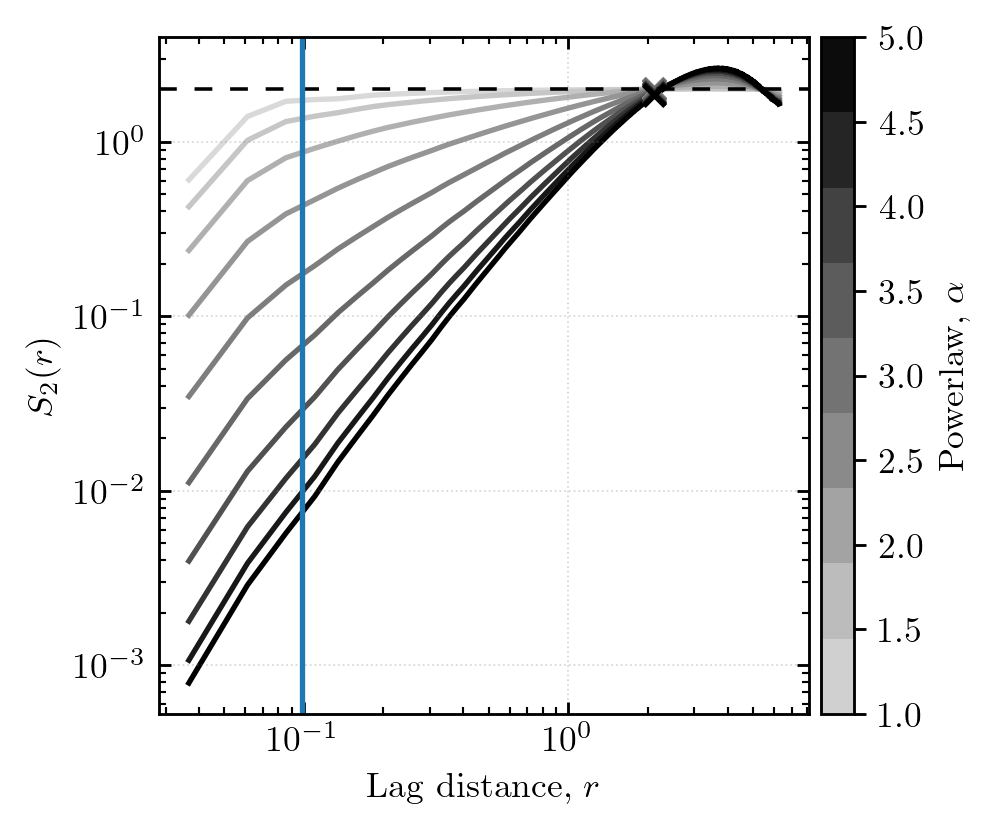

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i, lsf in enumerate(bin_sfs):
    bin_l, bin_sf, w = lsf
    ax.loglog(bin_l, bin_sf, zorder=0, color=cols[i])
    mmax = bin_sf[N//3]#np.nanmax(bin_sf)
    idx = np.where(bin_sf == mmax)
    im = ax.scatter(bin_l[idx], bin_sf[idx], zorder=1, marker='x', color=cols[i])

ax.axhline(2., color='black', linestyle=(0, (5,5)), linewidth=1.)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('$S_{2}(r)$')
ax.set_xlabel('Lag distance, $r$')

ax.axvline(2.*np.pi/BREAK)

In [5]:
def omni_spectrum_2(ell, sf2, phys_dims, grid_dims):
    dS = np.gradient(sf2, dx)
    dell = np.gradient(ell, dx)
    fek = (ell)**2 * (dS) * (twopi**D / 4.) / (twopi)
    #kk = 1. / ell
    kk = twopi / ell
    return kk[::-1], fek[::-1]

def omni_spectrum(ell, sf2, phys_dims, grid_dims):
    #kk = 1. / ell
    kk = twopi / ell
    fek = (twopi**D / 4.) * sf2 * ell / (twopi)
    return kk[::-1], fek[::-1]


Text(0.5, 0, 'Wavenumber, $k$')

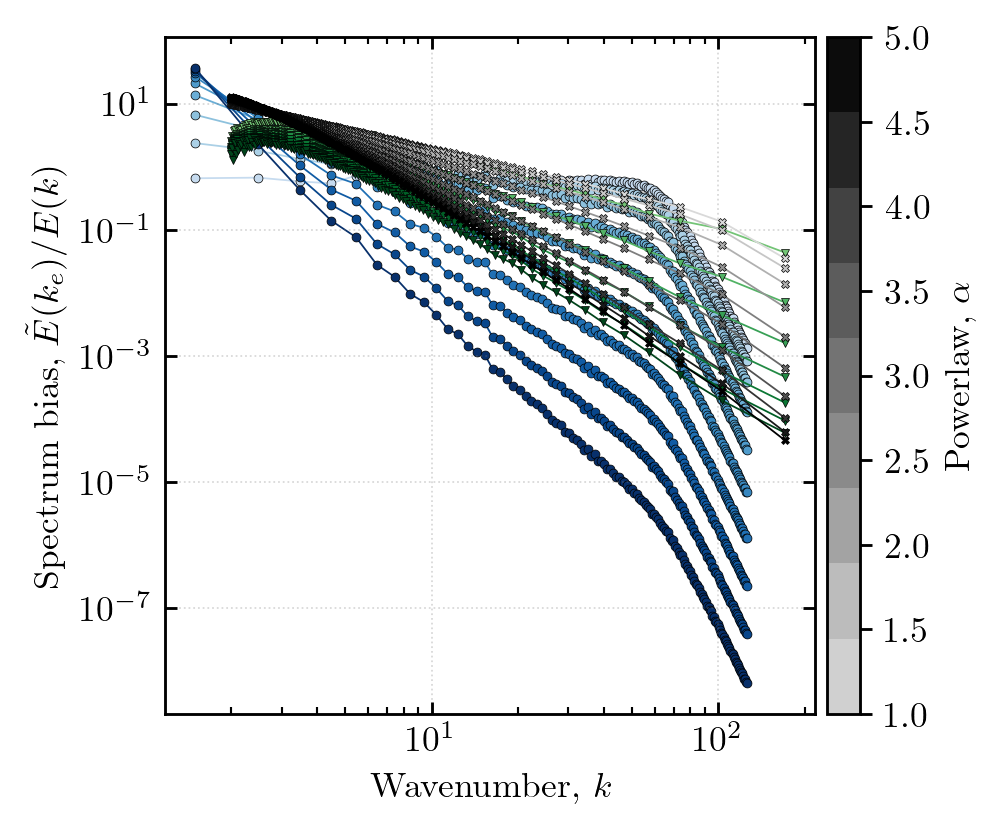

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i in range(len(sfs)):
    bin_l, bin_sf, w = bin_sfs[i]
    bin_l = bin_l[:N//2]
    bin_sf = bin_sf[:N//2]

    k, fek = omni_spectrum(bin_l, bin_sf, phys_dims, grid_dims)
    ax.plot(k, fek, color=cols[i], linewidth=0.5, marker='X', markersize=2.5, zorder=2, markeredgewidth=0.2, markeredgecolor='black')

    k, fek = omni_spectrum_2(bin_l, bin_sf, phys_dims, grid_dims)
    ax.plot(k, fek / (-alphas[i] - D), linewidth=0.5, color=cols3[i], marker='v', markersize=2.5, zorder=1, markeredgewidth=0.2, markeredgecolor='black')

    ax.plot(ospecs[i][0], ospecs[i][1] * ospecs[i][2], linewidth=0.5, color=cols2[i], marker='o', markersize=2.5, zorder=0, markeredgewidth=0.2, markeredgecolor='black')

ax.set_yscale('log')
ax.set_xscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Spectrum bias, $\\tilde{E}(k_{e})/E(k)$')
ax.set_xlabel('Wavenumber, $k$')

/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


Text(0.5, 0, 'Wavenumber, $k$')

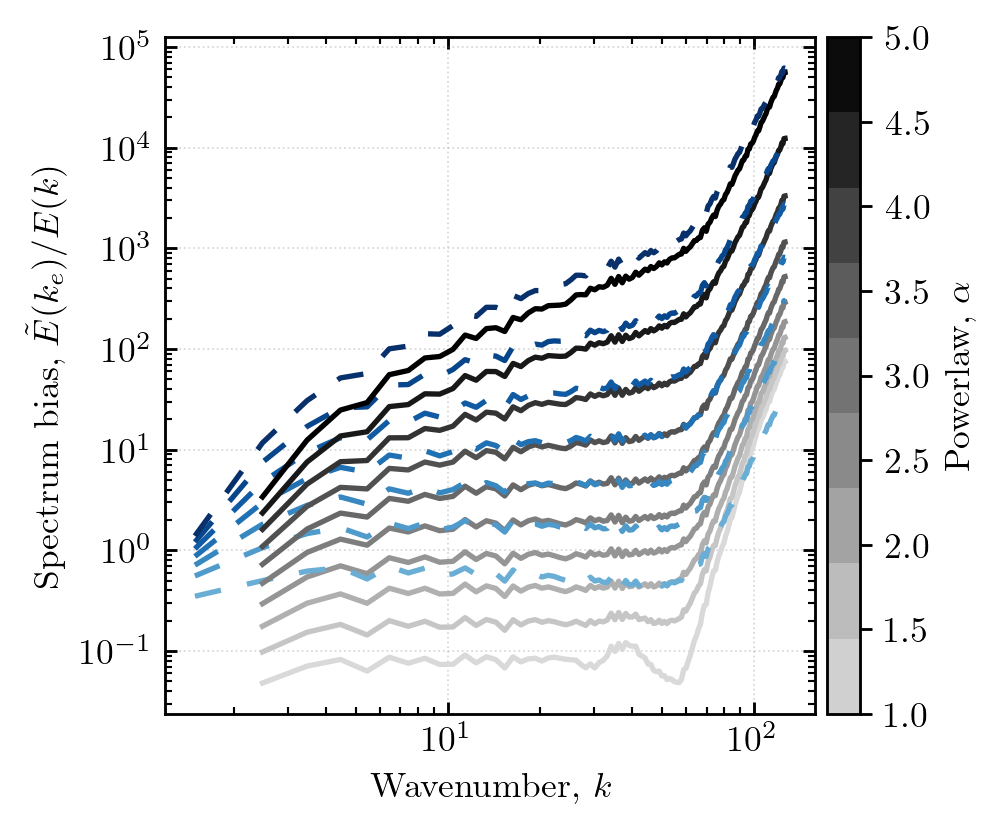

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i in range(len(sfs)):
    bin_l, bin_sf, w = bin_sfs[i]
    k, fek = omni_spectrum_2(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])
    ax.loglog(ospecs[i][0], int_fek / ospecs[i][1] / ospecs[i][2], color=cols[i])

    k, fek = omni_spectrum(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])
    ax.loglog(ospecs[i][0], int_fek * (-alphas[i] - D) / ospecs[i][1] / ospecs[i][2], linestyle=(0,(5,5)), color=cols2[i])

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Spectrum bias, $\\tilde{E}(k_{e})/E(k)$')
ax.set_xlabel('Wavenumber, $k$')

Text(0.5, 0, 'Powerlaw, $\\alpha$')

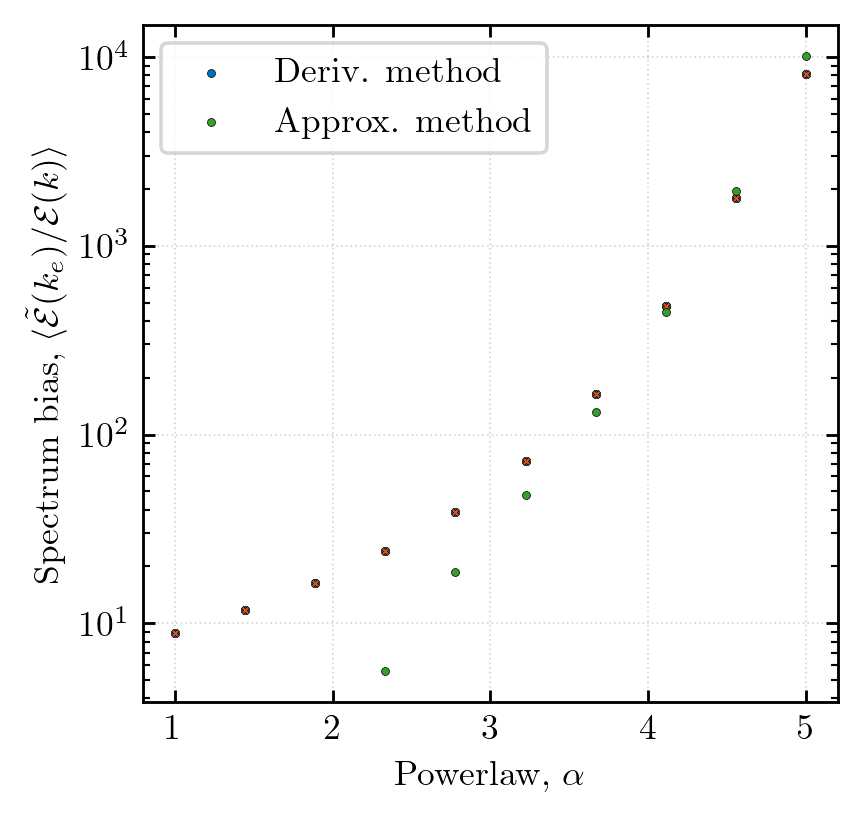

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i in range(len(sfs)):
    bin_l, bin_sf, w = bin_sfs[i]
    k, fek = omni_spectrum_2(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])
    ax.scatter(-alphas[i], np.nanmean(int_fek / ospecs[i][1] / ospecs[i][2]), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

    int_fekm = int_fek / statistics_base.kern_center(ospecs[i][0], D, ospecs[i][2], dk)
    ax.scatter(-alphas[i], np.nanmean(int_fekm / mspecs[i][1] / mspecs[i][2]), marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

    k, fek = omni_spectrum(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])

    ax.scatter(-alphas[i], np.nanmean(int_fek * (-alphas[i] - D) / ospecs[i][1] / ospecs[i][2]), marker='o', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
    #/ (alphas[i] + 2)

ax.scatter([], [], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', label='Deriv. method')
ax.scatter([], [], marker='o', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black', label='Approx. method')

ax.legend()

ax.set_yscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Spectrum bias, $\langle \\tilde{\mathcal{E}}(k_{e})/\mathcal{E}(k) \\rangle$')
ax.set_xlabel('Powerlaw, $\\alpha$')

Text(0.5, 0, 'Powerlaw, $\\alpha$')

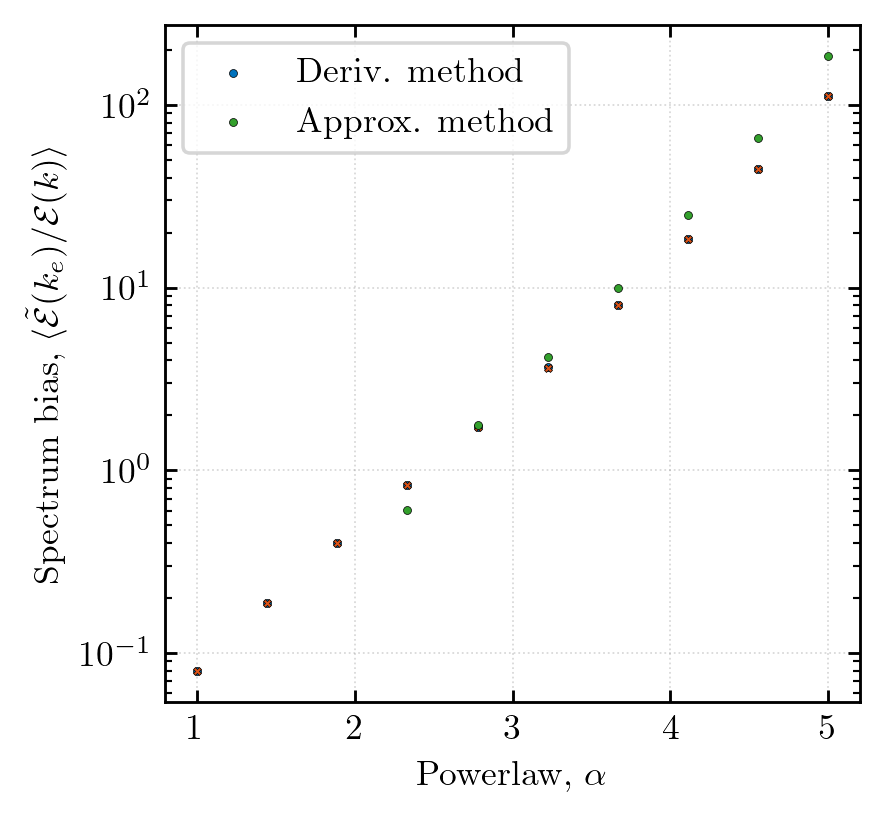

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i in range(len(sfs)):
    bin_l, bin_sf, w = bin_sfs[i]
    k, fek = omni_spectrum_2(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])
    ax.scatter(-alphas[i], np.nanmean(int_fek[5:15] / ospecs[i][1][5:15] / ospecs[i][2][5:15]), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

    int_fekm = int_fek / statistics_base.kern_center(ospecs[i][0], D, ospecs[i][2], dk)
    ax.scatter(-alphas[i], np.nanmean(int_fekm[5:15] / mspecs[i][1][5:15] / mspecs[i][2][5:15]), marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

    k, fek = omni_spectrum(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])

    ax.scatter(-alphas[i], np.nanmean(int_fek[5:15] * (-alphas[i] - D) / ospecs[i][1][5:15] / ospecs[i][2][5:15]), marker='o', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
    #/ (alphas[i] + 2)

ax.scatter([], [], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', label='Deriv. method')
ax.scatter([], [], marker='o', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black', label='Approx. method')

ax.legend()

ax.set_yscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Spectrum bias, $\langle \\tilde{\mathcal{E}}(k_{e})/\mathcal{E}(k) \\rangle$')
ax.set_xlabel('Powerlaw, $\\alpha$')